## Plant Seedlings Classification

## Problem Statement

### Context

In recent times, the field of agriculture has been in urgent need of modernizing, since the amount of manual work people need to put in to check if plants are growing correctly is still highly extensive. Despite several advances in agricultural technology, people working in the agricultural industry still need to have the ability to sort and recognize different plants and weeds, which takes a lot of time and effort in the long term. The potential is ripe for this trillion-dollar industry to be greatly impacted by technological innovations that cut down on the requirement for manual labor, and this is where Artificial Intelligence can actually benefit the workers in this field, as **the time and energy required to identify plant seedlings will be greatly shortened by the use of AI and Deep Learning.** The ability to do so far more efficiently and even more effectively than experienced manual labor, could lead to better crop yields, the freeing up of human inolvement for higher-order agricultural decision making, and in the long term will result in more sustainable environmental practices in agriculture as well.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from Olympus.
- The data file names are:
    - images.npy
    - Labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass
- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
!pip install tensorflow==2.15.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 opencv-python==4.8.0.76 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.7 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-s

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
#!pip install tensorflow==2.13.0 scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 opencv-python==4.8.0.76 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# Import all liberaries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import cv2
import seaborn as sns
import time

# Tensorflow modules
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam,SGD
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelBinarizer
# Display images using OpenCV
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend
from keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix,classification_report
import random
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [ ]:
# Import Files

from google.colab import drive
drive.mount('/content/drive')

images = np.load('/content/drive/My Drive/AIML_Class_Files/ComputerVision_Capstone/images.npy')
labels = pd.read_csv('/content/drive/My Drive/AIML_Class_Files/ComputerVision_Capstone/Labels.csv')


Mounted at /content/drive


## Data Overview

### Understand the shape of the dataset

In [ ]:
# Shape of images

print(images.shape)
print(labels.shape)

(4750, 128, 128, 3)
(4750, 1)


#### Observation
Shape of Images
- We have 4750 Images
- Each Color Image is of 128x128
- Number of Labels are also 4750

label[0] Small-flowered Cranesbill


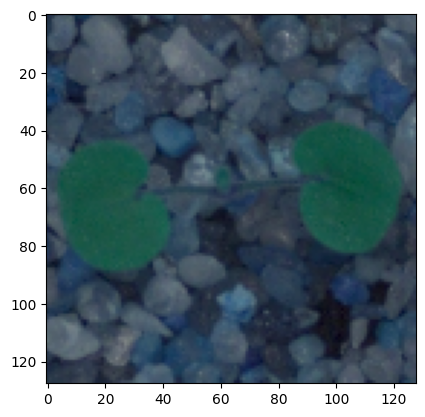

In [ ]:
# Print few Images & Label

print('label[0]', labels['Label'][0])
plt.imshow(images[0])


label[500] Fat Hen


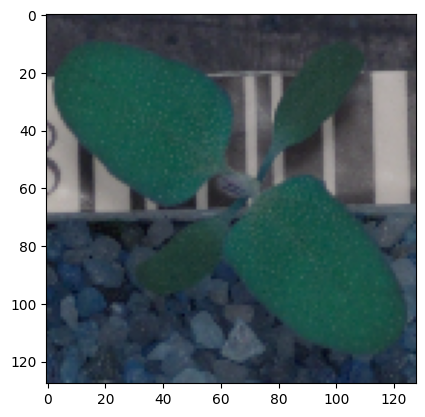

In [ ]:
# Show Image 500 and its label

print('label[500]', labels['Label'][500])
plt.imshow(images[500])

#### Observations
- Above show few Images from the Image file.

## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you understand the data better.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

1. How are these different category plant images different from each other?
2. Is the dataset provided an imbalance? (Check with using bar plots)

In [ ]:
# Number of Categories

print('Number of Categories\n',labels['Label'].value_counts())

Number of Categories
 Label
Loose Silky-bent             654
Common Chickweed             611
Scentless Mayweed            516
Small-flowered Cranesbill    496
Fat Hen                      475
Charlock                     390
Sugar beet                   385
Cleavers                     287
Black-grass                  263
Shepherds Purse              231
Common wheat                 221
Maize                        221
Name: count, dtype: int64


#### Observations
- Number of Unique Categories - 12
- Value Count of each category are given


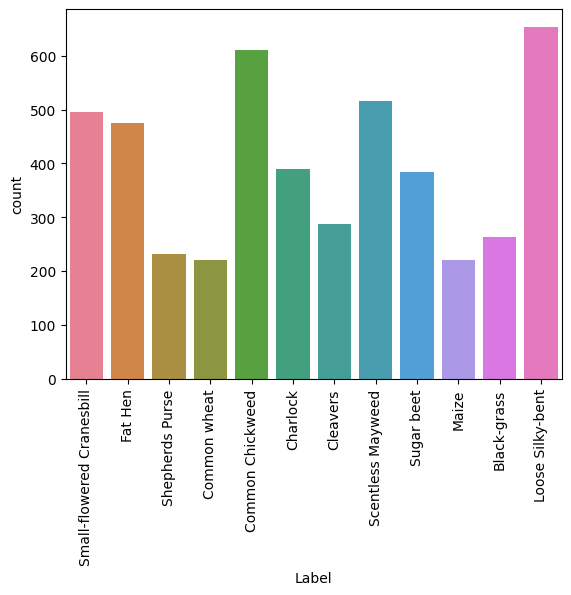

In [ ]:
# Count Chart of the Plant Labels

plt.xticks(rotation=90)
sns.countplot(data=labels, x='Label', hue='Label', orient='v')
plt.show();

#### Observation
- We can see that the certian category / class of Plant Images are higher in count, with variatin from ~600 to 200 counts
- We might have to treat the imbalance if needed.

## Data Pre-Processing

### Convert the BGR images to RGB images.

In [ ]:
# Converting the images from BGR to RGB
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

#### Observations
- Image is converts to RGB from BRG

### Resize the images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.

In [ ]:
images_resize=[]
height = 64
width =  64
dimensions = (width, height)
for i in range(len(images)):
  images_resize.append(cv2.resize(images[i], dimensions, interpolation=cv2.INTER_LINEAR))

Shape before Resize:  (128, 128, 3)
Shape After Resize:  (64, 64, 3)


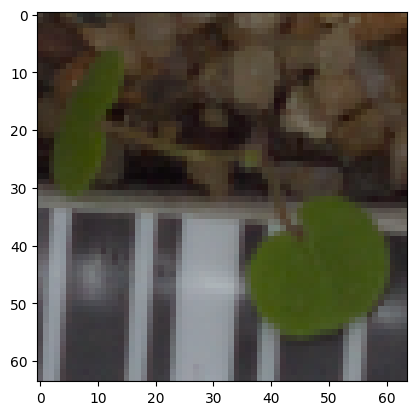

In [ ]:
# Shape of image after ReSize

print('Shape before Resize: ', images[10].shape)
print('Shape After Resize: ', images_resize[10].shape)

plt.imshow(images_resize[10]);

#### Observation
- We can see that the Object has been re-sized

### Data Preparation for Modeling

- Before you proceed to build a model, you need to split the data into train, test, and validation to be able to evaluate the model that you build on the train data
- You'll have to encode categorical features and scale the pixel values.
- You will build a model using the train data and then check its performance

**Split the dataset**

In [ ]:
# Splitting the data into Train, Test, Validate
# Validation will be a 20% of

X = np.array(images_resize)
y = labels.to_numpy()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, train_size = 0.8, random_state=1, shuffle=True, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, train_size = 0.8, random_state=1, shuffle=True)


In [ ]:
# Print all the Value Counts

print('X_train, y_train Shape', X_train.shape, y_train.shape)
print('X_val, y_val Shape', X_val.shape, y_val.shape)
print('X_test, y_test Shape', X_test.shape, y_test.shape)

X_train, y_train Shape (3040, 64, 64, 3) (3040, 1)
X_val, y_val Shape (760, 64, 64, 3) (760, 1)
X_test, y_test Shape (950, 64, 64, 3) (950, 1)


#### Observations
- We split the data inot
  - Training - 3040
  - Validation - 760
  - Testing - 950

### Encode the target labels

In [ ]:
# Encode Target Variables

enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)

y_test_encoded[1]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

#### Observations
- Encoded all three Arrays
  - y_test, y_val, y_train


### Data Normalization

In [ ]:
# Normalization of Input Array

X_train_normalized = X_train.astype('float32') / 255.0
X_val_normalized = X_val.astype('float32')  / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

#### Observations
- We have Normalized the input as well
  - X_train, X_val, X_test

## Model Building

In [ ]:
# Initializing & Seeding

backend.clear_session()
np.random.seed(1)
random.seed(1)
tf.random.set_seed(1)

In [ ]:
# Create Utility Funcation for Neural Network Visualization

def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [ ]:
# Build the Convolutional NN model

image_model = Sequential()

# Add Convolutional NN - Layer1
image_model.add(Conv2D(128, (3,3), padding='same', activation='relu', input_shape=(64,64,3)))
image_model.add(MaxPooling2D((2,2), padding='same'))

# ConvNN  - Layer2
image_model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
image_model.add(MaxPooling2D((2,2), padding='same'))

# ConvNN - Layer3
image_model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
image_model.add(MaxPooling2D((2,2), padding='same'))

# Flatten the output
image_model.add(Flatten())

image_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95,840 (374.38 KB)

 Trainable params: 95,840 (374.38 KB)

 Non-trainable params: 0 (0.00 B)

#### Observations
- We have created the Initial Convolutional Model
  - Total Trainable Param - 95,840
  - We have three Layers of Convolution
  - Padding has been done and Max Poolign to optimize compitation

In [ ]:
# Addingn ANN Dense Layer for Training Computations.

image_model.add(Dense(16, activation='relu'))
image_model.add(Dense(12, activation='softmax'))

image_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │          32,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 128,828 (503.23 KB)

 Trainable params: 128,828 (503.23 KB)

 Non-trainable params: 0 (0.00 B)

#### Observations
- We added the Dense Layer of 16 Neurona
- Output Layer is of 12 Neurons that represent output classes.

In [ ]:
# Configuring NN Optimizer
# We chose Adam Optimizer for our NN Computation.

optimizer = keras.optimizers.Adam(learning_rate=0.01)
image_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

image_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │          32,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 128,828 (503.23 KB)

 Trainable params: 128,828 (503.23 KB)

 Non-trainable params: 0 (0.00 B)

#### Observations
- We chose Adam Optimizer with Learnign Rate of 0.01
- Metric chosend for Validation and Comparison is Accuracy.

In [ ]:
# Fitting the Model

start_time = time.time()
image_model_train = image_model.fit(X_train_normalized, y_train_encoded, batch_size=32, epochs=20, validation_data=(X_val_normalized,y_val_encoded))
end_time = time.time()

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 837ms/step - accuracy: 0.1177 - loss: 2.5029 - val_accuracy: 0.1197 - val_loss: 2.4189
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 850ms/step - accuracy: 0.1264 - loss: 2.4139 - val_accuracy: 0.1382 - val_loss: 2.4152
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 842ms/step - accuracy: 0.1361 - loss: 2.4102 - val_accuracy: 0.1382 - val_loss: 2.4152
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 80s 821ms/step - accuracy: 0.1361 - loss: 2.4100 - val_accuracy: 0.1382 - val_loss: 2.4153
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 814ms/step - accuracy: 0.1362 - loss: 2.4099 - val_accuracy: 0.1382 - val_loss: 2.4153
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 803ms/step - accuracy: 0.1362 - loss: 2.4099 - val_accuracy: 0.1382 - val_loss: 2.4153
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 85s 844ms/step - accuracy: 0.1362 - loss: 2.4099 - val_accuracy: 0.1382 - val_loss: 2.4153
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 78s 801ms/step - accuracy: 0.1362 - loss: 2.4098 - val_accu

#### Observations
- Model Training was done undr the following parameters
  - Epoch = 20
  - Batch Size = 32

- We cn see that the Accuracy and Loss are hlding steady
- Validation Loss is lowere than Training Loss numbers
- Accuracy of Validation is higher then Training
- There is no Over Fitting.
- But we need to see if ClassImbalance is affecting the Training

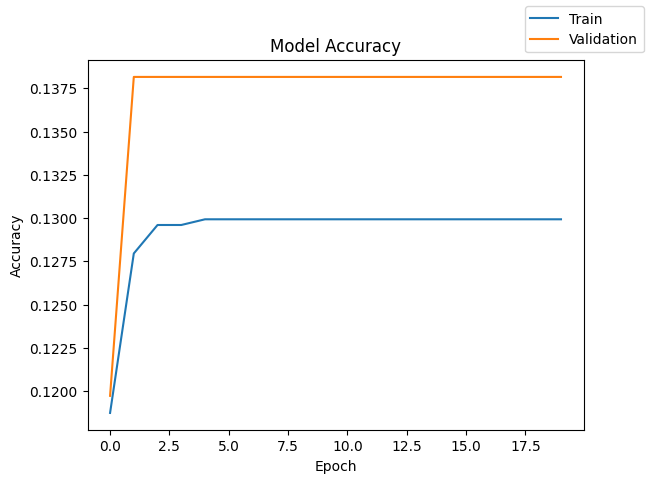

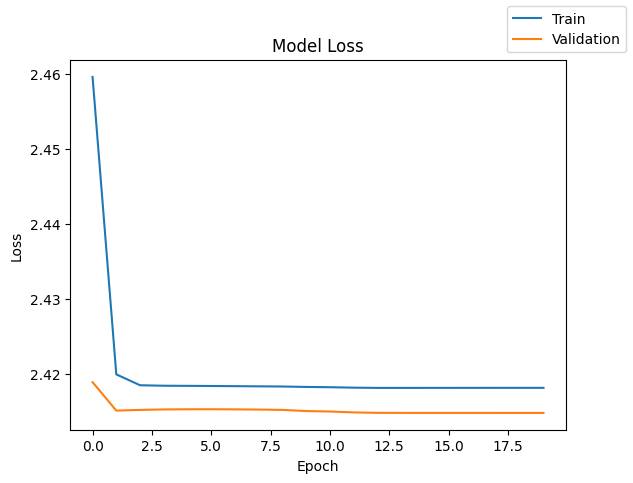

In [ ]:
plot(image_model_train, 'accuracy')
plot(image_model_train, 'loss')

In [ ]:
# Evaluatin the Model with Test Data

accuracy = image_model.evaluate(X_test_normalized, y_test_encoded, verbose=2)

30/30 - 9s - 287ms/step - accuracy: 0.1379 - loss: 2.4160


#### Observation
- With test data teh Accuracy and Loss is very much in-line with what was obsrvered.


In [ ]:
# Predictign the results class using Probabilities.

y_test_predict = image_model.predict(X_test_normalized)

y_test_predict

30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 377ms/step


array([[0.05497359, 0.08378596, 0.06435508, ..., 0.04982361, 0.09909638,
        0.0804923 ],
       [0.05497359, 0.08378596, 0.06435508, ..., 0.04982361, 0.09909638,
        0.0804923 ],
       [0.05497359, 0.08378596, 0.06435508, ..., 0.04982361, 0.09909638,
        0.0804923 ],
       ...,
       [0.05497359, 0.08378596, 0.06435508, ..., 0.04982361, 0.09909638,
        0.0804923 ],
       [0.05497359, 0.08378596, 0.06435508, ..., 0.04982361, 0.09909638,
        0.0804923 ],
       [0.05497359, 0.08378596, 0.06435508, ..., 0.04982361, 0.09909638,
        0.0804923 ]], dtype=float32)

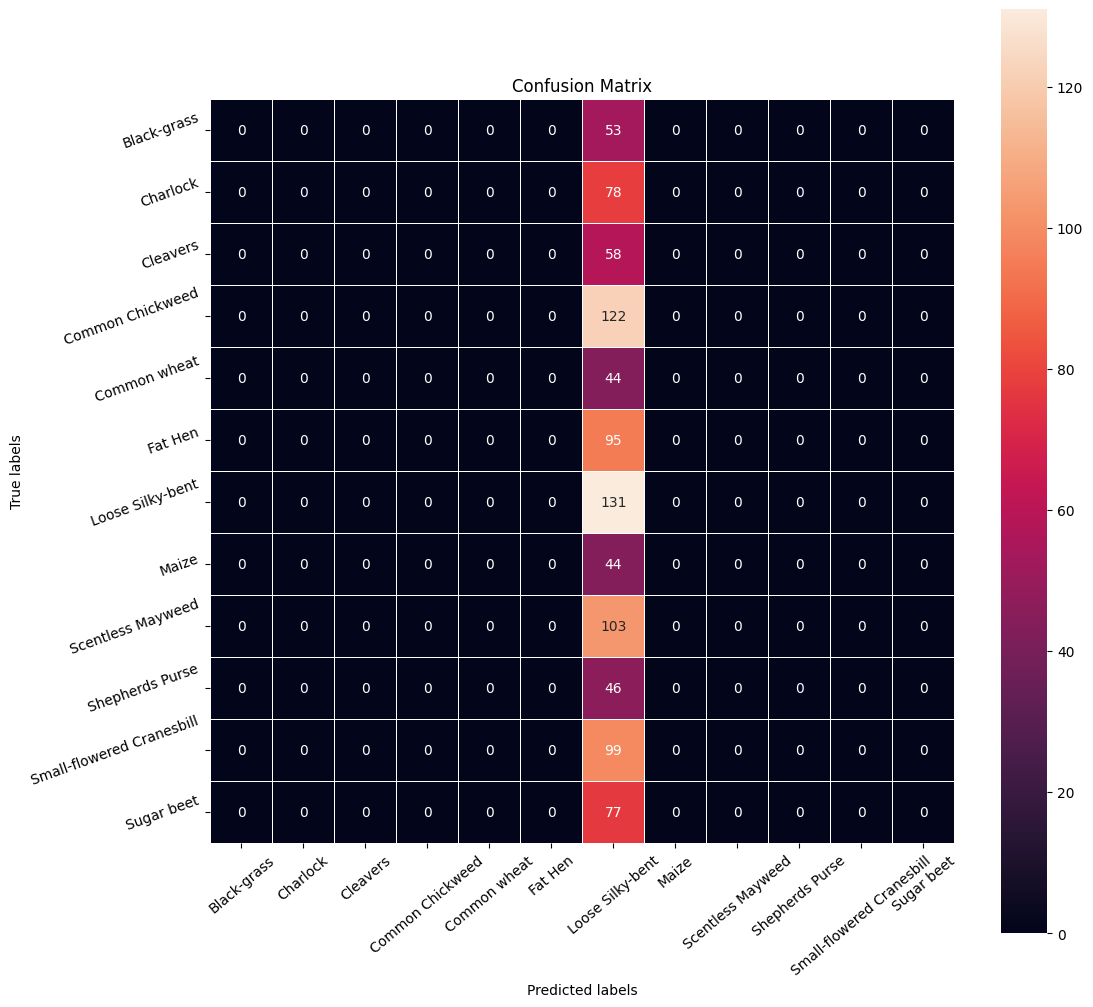

In [ ]:
# Creating a Heat Map from Test & Predicted result

y_pred_arg=np.argmax(y_test_predict,axis=1)
y_test_arg=np.argmax(y_test_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)              # Complete the code to plot the confusion matrix
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=20)
plt.show()

#### Observation,
- It is observed that the Idntification is not happenign properly.
- We will see is Class Imbalance is affecting the identification using Data Augmentation.

## Model Performance Improvement

**Reducing the Learning Rate:**

**Hint**: Use **ReduceLRonPlateau()** function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

In [ ]:
# Code to monitor val_accuracy
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

### **Data Augmentation**

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
# Clearing backend

backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(1)
random.seed(1)
tf.random.set_seed(1)

In [ ]:
train_image_gen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest'
                              )

In [ ]:
# Intializing a sequential model
image_model2 = Sequential()

# Convolutin NN - layer1
image_model2.add(Conv2D(64, (3,3), activation='relu', padding="same", input_shape=(64, 64, 3)))
image_model2.add(MaxPooling2D((2, 2), padding = 'same'))

# Convolutin NN - layer2
image_model2.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
image_model2.add(MaxPooling2D((2, 2), padding = 'same'))
image_model2.add(BatchNormalization())

image_model2.add(Flatten())

# Adding ANN Layer
image_model2.add(Dense(16, activation='relu'))
image_model2.add(Dropout(0.3))
image_model2.add(Dense(12, activation='softmax'))

# Complete the code to initialize Adam Optimimzer
optimizer = keras.optimizers.Adam(learning_rate=0.01)
image_model2.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

image_model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │         131,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,676 (592.48 KB)

 Trainable params: 151,612 (592.23 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
# Fitting the Model

start_time = time.time()
image_model_train2 = image_model2.fit(train_image_gen.flow(X_train_normalized,y_train_encoded,batch_size=32, shuffle=False), epochs=20, validation_data=(X_val_normalized,y_val_encoded), verbose=1,callbacks=[learning_rate_reduction])
end_time = time.time()

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 380ms/step - accuracy: 0.1249 - loss: 2.6366 - val_accuracy: 0.1382 - val_loss: 2.4200 - learning_rate: 0.0100
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 33s 349ms/step - accuracy: 0.1300 - loss: 2.4280 - val_accuracy: 0.1382 - val_loss: 2.4148 - learning_rate: 0.0100
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 33s 348ms/step - accuracy: 0.1430 - loss: 2.4113 - val_accuracy: 0.1382 - val_loss: 2.4158 - learning_rate: 0.0100
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.1369 - loss: 2.4090
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
95/95 ━━━━━━━━━━━━━━━━━━━━ 33s 344ms/step - accuracy: 0.1368 - loss: 2.4091 - val_accuracy: 0.1382 - val_loss: 2.4151 - learning_rate: 0.0100
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 352ms/step - accuracy: 0.1250 - loss: 2.4234 - val_accuracy: 0.1382 - val_loss: 2.4150 - learning_rate: 0.0050
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 33s 348ms/step - accuracy: 0.1468 - loss: 2.417

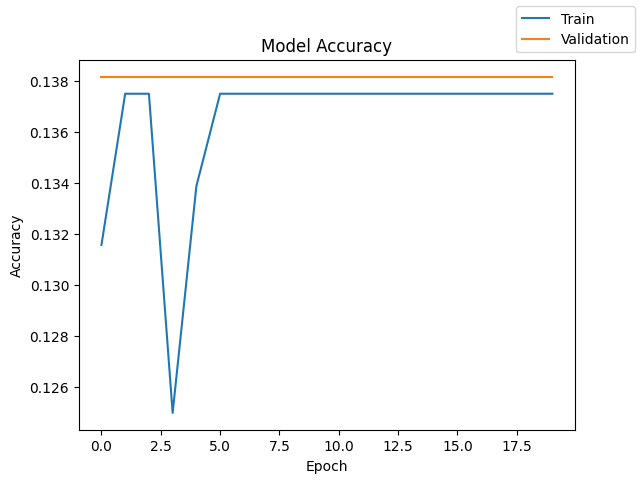

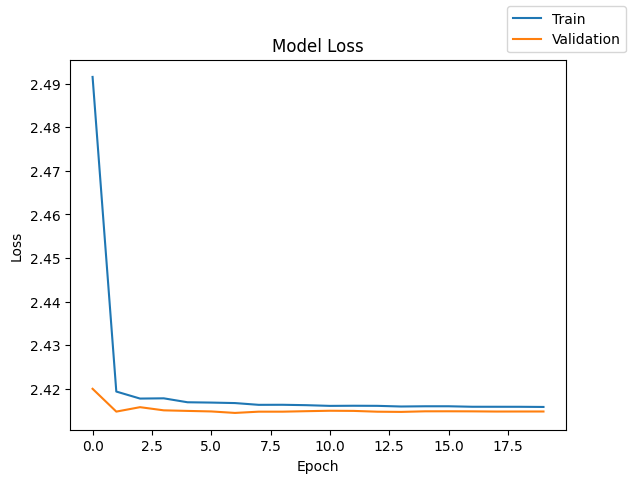

In [ ]:
# Plot Accuracy & Loss Funcation

plot(image_model_train2, 'accuracy')
plot(image_model_train2, 'loss')

In [ ]:
# Evaluate Accuray

accuracy = image_model2.evaluate(X_test_normalized, y_test_encoded, verbose=2)

30/30 - 2s - 57ms/step - accuracy: 0.1379 - loss: 2.4157


In [ ]:
# Predicting teh Results

y_test_predict = image_model2.predict(X_test_normalized)

y_test_predict[1]

30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step


array([0.05654503, 0.08355832, 0.06511908, 0.13094233, 0.04726383,
       0.09778437, 0.13749914, 0.04450382, 0.1078393 , 0.04758251,
       0.10223566, 0.07912659], dtype=float32)

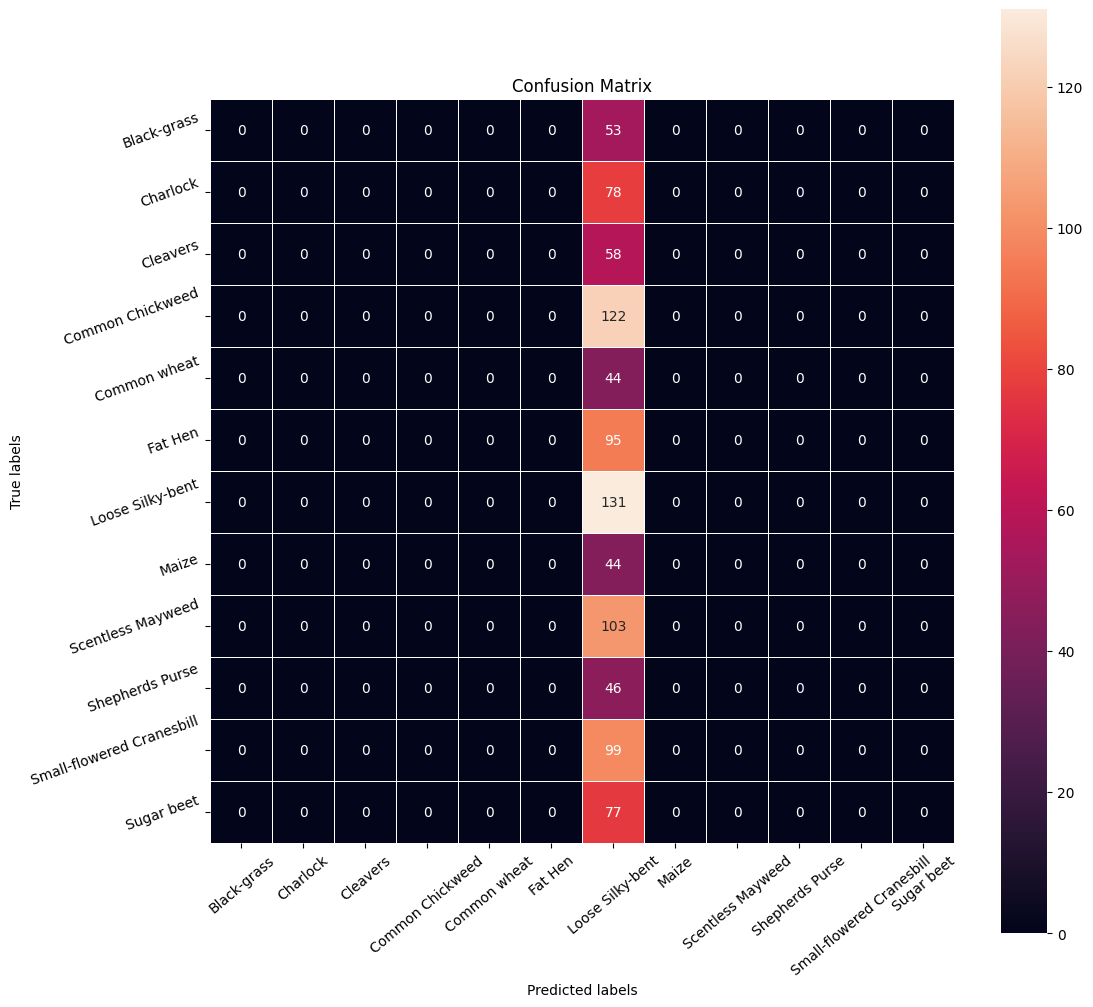

In [77]:
# Plotting Confusion Metrix
y_pred_arg=np.argmax(y_test_predict,axis=1)
y_test_arg=np.argmax(y_test_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg, y_pred_arg)
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=20)
plt.show()

## Final Model

- Optimized Model is alsonot showiong proper accuracy, We need to anlyse this mode furtehr since several of teh predictions are even acorss the board.
- Optimized Model seems to give better result compared to Non Optimzed Model though the results are close.

### Visualizing the prediction

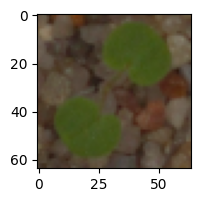

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Label ['Loose Silky-bent']
True Label Small-flowered Cranesbill


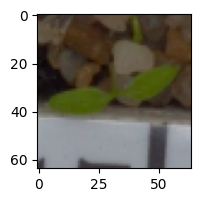

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted Label ['Loose Silky-bent']
True Label Common Chickweed


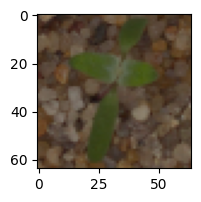

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicted Label ['Loose Silky-bent']
True Label Fat Hen


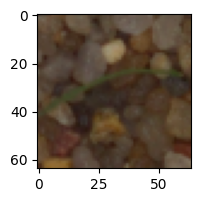

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted Label ['Loose Silky-bent']
True Label Loose Silky-bent


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_test[2])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(image_model2.predict((X_test_normalized[2].reshape(1,64,64,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[33])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(image_model2.predict((X_test_normalized[33].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[33])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[59],)
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(image_model2.predict((X_test_normalized[59].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[59])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[36])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(image_model2.predict((X_test_normalized[36].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[36])                                              # using inverse_transform() to get the output label from the output vector

## Actionable Insights and Business Recommendations

- The Predictions are not very accuracte looking at confusion metrix
- We need run more test to see how best we can improve the result.

_____